In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/jena_climate_2009_2016.csv')

In [ ]:
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420451 entries, 0 to 420450
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Date Time        420451 non-null  object 
 1   p (mbar)         420451 non-null  float64
 2   T (degC)         420451 non-null  float64
 3   Tpot (K)         420451 non-null  float64
 4   Tdew (degC)      420451 non-null  float64
 5   rh (%)           420451 non-null  float64
 6   VPmax (mbar)     420451 non-null  float64
 7   VPact (mbar)     420451 non-null  float64
 8   VPdef (mbar)     420451 non-null  float64
 9   sh (g/kg)        420451 non-null  float64
 10  H2OC (mmol/mol)  420451 non-null  float64
 11  rho (g/m**3)     420451 non-null  float64
 12  wv (m/s)         420451 non-null  float64
 13  max. wv (m/s)    420451 non-null  float64
 14  wd (deg)         420451 non-null  float64
dtypes: float64(14), object(1)
memory usage: 48.1+ MB


**discovering nulls and filling it**

In [ ]:
df.isna().sum()

,0
Date Time,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0


In [ ]:
df = df.interpolate()
#as our data has nulls between small gaps so that we can filling with interpolation safely

/tmp/ipython-input-4248604237.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df = df.interpolate()


In [ ]:
df.isnull().sum()

,0
Date Time,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0


# **feature engineering (circular encoding)**

In [ ]:
#adapting data types to be in date time format
df['Date Time'] = pd.to_datetime(df['Date Time'] , format='mixed')
df = df.set_index('Date Time')


In [ ]:
# This part is for showing the hours that doesn't exist in the original dataset
# Where pandas create rows for these hours even they don't exist in the orignal dataset
counts = df.resample("1H").count()
counts[counts == 0].dropna(how="all")


/tmp/ipython-input-772640908.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  counts = df.resample("1H").count()


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2014-09-24 18:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-24 19:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-24 20:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-24 21:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2014-09-24 22:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2016-10-28 07:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-10-28 08:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2016-10-28 09:00:00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:

#1- resampling data to be hourly instead of 10 min interval
df_hourly = df.resample('1H').mean().reset_index()

/tmp/ipython-input-3356482445.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('1H').mean().reset_index()


In [ ]:
#2- adding col hour , month but using the sin and cos as i want the cyclicity means in month (1 - 12 )are adjecents
# extracting raw hour and month integers
df_hourly['hour'] = df_hourly['Date Time'].dt.hour

#For Hour (Max Value = 24)
hours_in_day = 24
df_hourly['hour_sin'] = np.sin(df_hourly['hour'] * (2. * np.pi / hours_in_day))
df_hourly['hour_cos'] = np.cos(df_hourly['hour'] * (2. * np.pi / hours_in_day))

#MODIFICATION_2
#Seasonal cycle (day of year - more precise than month)
df_hourly['day_of_year'] = df_hourly['Date Time'].dt.dayofyear
df_hourly['doy_sin'] = np.sin(2*np.pi*df_hourly['day_of_year']/365.25)
df_hourly['doy_cos'] = np.cos(2*np.pi*df_hourly['day_of_year']/365.25)


In [ ]:
df_hourly.isnull().sum()

,0
Date Time,0
p (mbar),104
T (degC),104
Tpot (K),104
Tdew (degC),104
rh (%),104
VPmax (mbar),104
VPact (mbar),104
VPdef (mbar),104
sh (g/kg),104


In [ ]:
df_hourly = df_hourly.interpolate()


In [ ]:
df_hourly.isnull().sum().sum()

np.int64(0)

In [ ]:
df.head(10)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
2009-01-01 01:00:00,996.50,-8.05,265.38,-8.78,94.4,3.33,3.14,0.19,1.96,3.15,1307.86,0.21,0.63,192.7
2009-01-01 01:10:00,996.50,-7.62,265.81,-8.30,94.8,3.44,3.26,0.18,2.04,3.27,1305.68,0.18,0.63,166.5
2009-01-01 01:20:00,996.50,-7.62,265.81,-8.36,94.4,3.44,3.25,0.19,2.03,3.26,1305.69,0.19,0.50,118.6
2009-01-01 01:30:00,996.50,-7.91,265.52,-8.73,93.8,3.36,3.15,0.21,1.97,3.16,1307.17,0.28,0.75,188.5


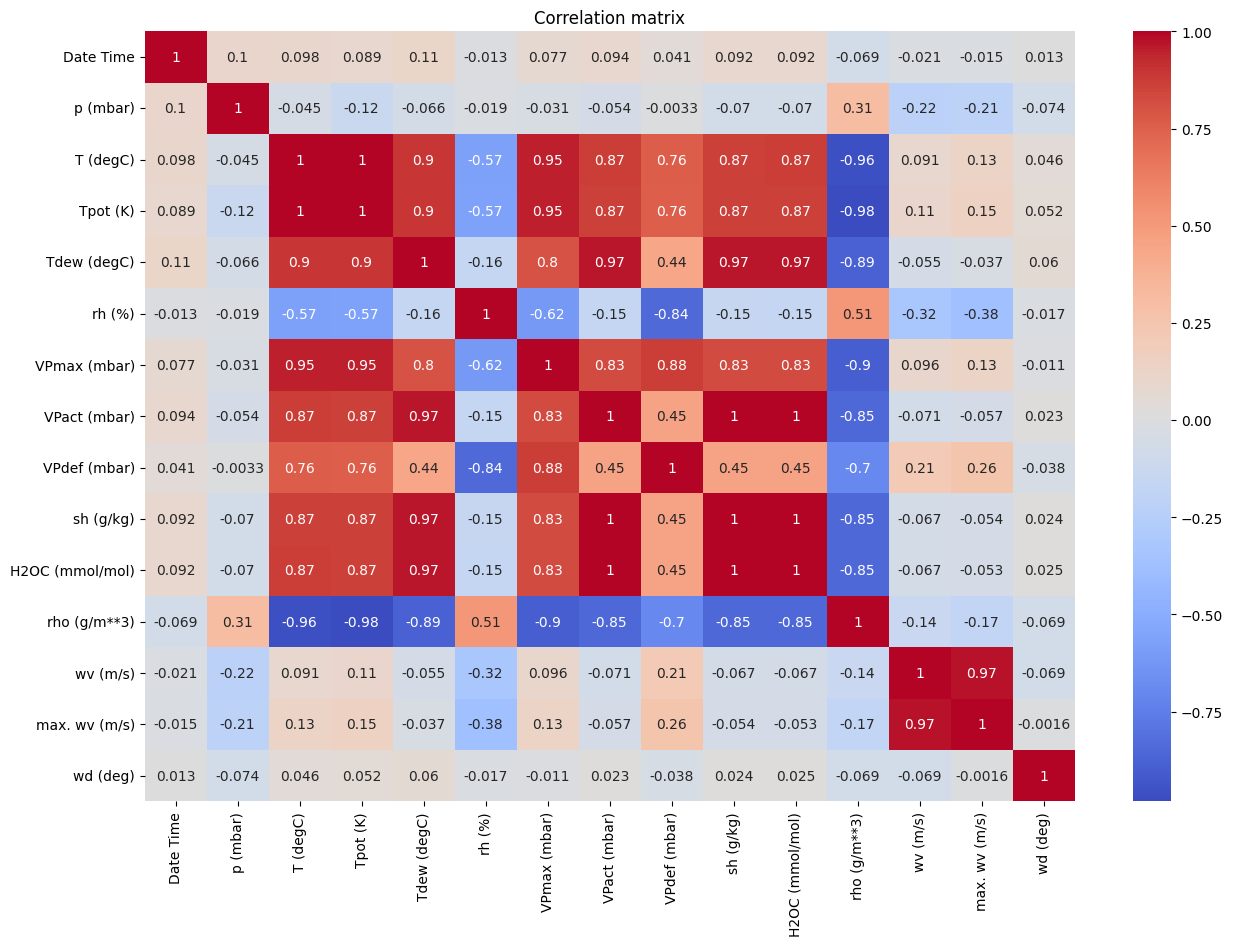

In [ ]:
#heatmap to see the correlations
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize= (15 , 10))
corr_mat= df_hourly.drop(columns=['hour_sin' , 'hour_cos' , 'doy_sin' , 'doy_cos' , 'hour' ,'day_of_year']).corr()
sns.heatmap(corr_mat , cmap='coolwarm' , annot = True)
plt.title('Correlation matrix')
plt.show()

## **droping unnessecary columns (really week correlation)**

In [ ]:
#Modification_3
#dropping the unnessecay cols that don't affect on out target like wd , wv also the highly correlated features like the same temp but with kilven
abs(corr_mat['T (degC)']).sort_values()
features_to_keep = [
        'T (degC)', 'p (mbar)', 'Tdew (degC)', 'rh (%)',
        'VPmax (mbar)', 'VPact (mbar)', 'sh (g/kg)',
        'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)',
        'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos'
    ]
df = df_hourly[features_to_keep]

## **splitting before normalization**

In [ ]:
#after preprocessing all the data (feature eng , drop unessecary cols ) except the normalizationnnn

#TEMPORAL SPLIT first
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_raw = df.iloc[:train_size].copy()
val_raw = df.iloc[train_size:train_size+val_size].copy()
test_raw = df.iloc[train_size+val_size:].copy()

print(f"Train: {train_raw.index[0]} to {train_raw.index[-1]}")
print(f"Val:   {val_raw.index[0]} to {val_raw.index[-1]}")
print(f"Test:  {test_raw.index[0]} to {test_raw.index[-1]}")


Train: 0 to 49089
Val:   49090 to 59608
Test:  59609 to 70128


## **Normalization using standard scaler but on each col separetly(better results)**

In [ ]:
# normalization
#normalizing each col separately and saving the scalers as i want to inverse the scalers while after the prediction

from sklearn.preprocessing import StandardScaler

# Initialize scalers (one per column)
scaler_dict = {}

# 5. Fit scalers ONLY on training data
for column in train_raw.columns:
    scaler = StandardScaler()
    scaler.fit(train_raw[[column]])  # ONLY TRAINING DATA!
    scaler_dict[column] = scaler

# 6. Transform all sets using TRAINING statistics
def scale_data(data_df, scaler_dict):
    scaled_df = pd.DataFrame(index=data_df.index)
    for column in data_df.columns:
        scaler = scaler_dict[column]
        scaled_df[column] = scaler.transform(data_df[[column]]).flatten()
    return scaled_df

train_scaled = scale_data(train_raw, scaler_dict)
val_scaled = scale_data(val_raw, scaler_dict)
test_scaled = scale_data(test_raw, scaler_dict)


#saving the scalers for using it in streamlit app latter
#already saved i will not run this again instead i will comment it
# import pickle
# import json
# import os

# # saving scalers for streamlit app
# # creating directory for artifacts (if it doesn't exist)
# artifacts_dir = 'preprocessing_artifacts'
# os.makedirs(artifacts_dir, exist_ok=True)

# # saving the COMPLETE scaler dictionary
# with open(f'{artifacts_dir}/scaler_dict.pkl', 'wb') as f:
#     pickle.dump(scaler_dict, f)

# print(f"✅ Saved {len(scaler_dict)} scalers to '{artifacts_dir}/scaler_dict.pkl'")



### ***Verifying applying normalization approperiatly***

In [ ]:
print("\n=== VERIFICATION ===")
print("Training data after scaling (should have ~mean=0, ~std=1):")
for col in ['T (degC)' , 'rh (%)']:
    print(f"  {col}: mean={train_scaled[col].mean():.6f}, std={train_scaled[col].std():.6f}")

print("\nTest data after scaling (using TRAINING statistics):")
for col in ['T (degC)','rh (%)']:
    print(f"  {col}: mean={test_scaled[col].mean():.6f}, std={test_scaled[col].std():.6f}")
    print(f"    (Note: Not exactly 0 and 1, which is CORRECT!)")


=== VERIFICATION ===
Training data after scaling (should have ~mean=0, ~std=1):
  T (degC): mean=0.000000, std=1.000010
  rh (%): mean=-0.000000, std=1.000010

Test data after scaling (using TRAINING statistics):
  T (degC): mean=0.072254, std=0.915838
    (Note: Not exactly 0 and 1, which is CORRECT!)
  rh (%): mean=0.017523, std=0.951222
    (Note: Not exactly 0 and 1, which is CORRECT!)


## ***Data Generation***

> (for predicting the temp for the next 12 h using the past 720 h (5 days)



In [ ]:
from tensorflow import keras
# Parameters
sequence_length = 72   #look for the previous 72 hours
sampling_rate = 1
batch_size = 128 # if i used 256 may cause potential overfitting , less genralization
delay = 12       #predicting the next 12 ones
target_col = 'T (degC)'  # Your target column


# ***converting into numy array to be appropriate for tensorflow***

In [ ]:
train_array = train_scaled.values
val_array = val_scaled.values
test_array = test_scaled.values

# Find temperature column index
target_idx = train_scaled.columns.get_loc(target_col)
print(f"Target column '{target_col}' is at index {target_idx}")

Target column 'T (degC)' is at index 0


## ***function for generation***

In [ ]:
# Function to create correctly aligned datasets
def create_multivariate_dataset(data_array, target_idx, sequence_length,
                                sampling_rate, delay, batch_size, shuffle=False):
    """
    Creates multivariate time series dataset with correct alignment

    Args:
        data_array: (n_timesteps, n_features) - ALL features
        target_idx: Index of temperature column
        sequence_length: Lookback window
        sampling_rate: How often to sample
        delay: How many steps ahead to predict
        batch_size: Batch size
        shuffle: Whether to shuffle (only for training)
    """
    # Calculate total offset
    total_offset = sequence_length + delay

    # Create targets: temperature at total_offset steps ahead
    # We need to align targets with the end of each input sequence
    targets = data_array[total_offset:, target_idx]  # Only temperature!

    # Input data: everything except the last 'delay' steps
    # (because we can't predict beyond available data)
    input_data = data_array[:-delay] if delay > 0 else data_array

    # Create dataset
    dataset = keras.utils.timeseries_dataset_from_array(
        data=input_data,
        targets=targets,
        sequence_length=sequence_length,
        sampling_rate=sampling_rate,
        sequence_stride=1,
        batch_size=batch_size,
        shuffle=shuffle,
        seed=42 if shuffle else None
    )

    return dataset

## **generation step**

In [ ]:

# Create datasets
print(f"\nCreating datasets with:")
print(f"  Sequence length: {sequence_length} steps ({sequence_length/24:.1f} days)")
print(f"  Sampling rate: {sampling_rate} (hourly samples)")
print(f"  Delay: {delay} steps ({delay/sampling_rate:.1f} hours ahead)")
print(f"  Batch size: {batch_size}")

train_dataset = create_multivariate_dataset(
    data_array=train_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=True  # Only for training
)

val_dataset = create_multivariate_dataset(
    data_array=val_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=False  # Never shuffle validation/test
)

test_dataset = create_multivariate_dataset(
    data_array=test_array,
    target_idx=target_idx,
    sequence_length=sequence_length,
    sampling_rate=sampling_rate,
    delay=delay,
    batch_size=batch_size,
    shuffle=False
)


Creating datasets with:
  Sequence length: 72 steps (3.0 days)
  Sampling rate: 1 (hourly samples)
  Delay: 12 steps (12.0 hours ahead)
  Batch size: 128


In [ ]:
# 3. VERIFICATION

print("\nStep 3: Verifying datasets...")

# Check one batch from each dataset
print("\nTraining dataset:")
for batch_x, batch_y in train_dataset.take(1):
    print(f"  Batch X shape: {batch_x.shape}")  # Should be (batch, seq_len, features)
    print(f"  Batch y shape: {batch_y.shape}")  # Should be (batch,)
    print(f"  Number of features: {batch_x.shape[2]}")
    print(f"  First target (scaled temp): {batch_y[0].numpy():.3f}")

print("\nValidation dataset:")
for batch_x, batch_y in val_dataset.take(1):
    print(f"  Batch X shape: {batch_x.shape}")
    print(f"  Batch y shape: {batch_y.shape}")


Step 3: Verifying datasets...

Training dataset:
  Batch X shape: (128, 72, 14)
  Batch y shape: (128,)
  Number of features: 14
  First target (scaled temp): 1.001

Validation dataset:
  Batch X shape: (128, 72, 14)
  Batch y shape: (128,)


In [ ]:
# normalization standard scaler -> done
# outlier threshold , visulaization , nulls -> inspect , clean -> done
# splitting data (720 past , 24 future) -> done
# date generation -> done

#**RNN before and after attention**

Reading input shape from dataset...
Input shape: (72, 14)

Starting model comparison...

TRAINING: SIMPLE RNN (NO ATTENTION)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 72, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 72, 14)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn_1        │ (None, 72, 32)    │      1,504 │ input_layer_1[0]… │
│ (SimpleRNN)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 72, 32)    │          0 │ simple_rnn_1[0][… │
│ (Attention)         │                   │            │ simple_rnn_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 32)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         17 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,049 (8.00 KB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - loss: 0.6779 - mae: 0.6278 - val_loss: 0.4686 - val_mae: 0.5151
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.5315 - mae: 0.5469 - val_loss: 0.3927 - val_mae: 0.4694
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.4259 - mae: 0.4858 - val_loss: 0.3736 - val_mae: 0.4644
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.3837 - mae: 0.4613 - val_loss: 0.3623 - val_mae: 0.4555
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.3653 - mae: 0.4514 - val_loss: 0.3775 - val_mae: 0.4752
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 0.3553 - mae: 0.4456 - val_loss: 0.3566 - val_mae: 0.4620
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.3411 - mae: 0.4364 - val_loss: 0.3569 - val_mae: 0.4661
Epoch 8/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.3325 - mae: 0.4315 - val_loss: 0.3609 - val_mae: 0.4652
Epoch 9/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 10

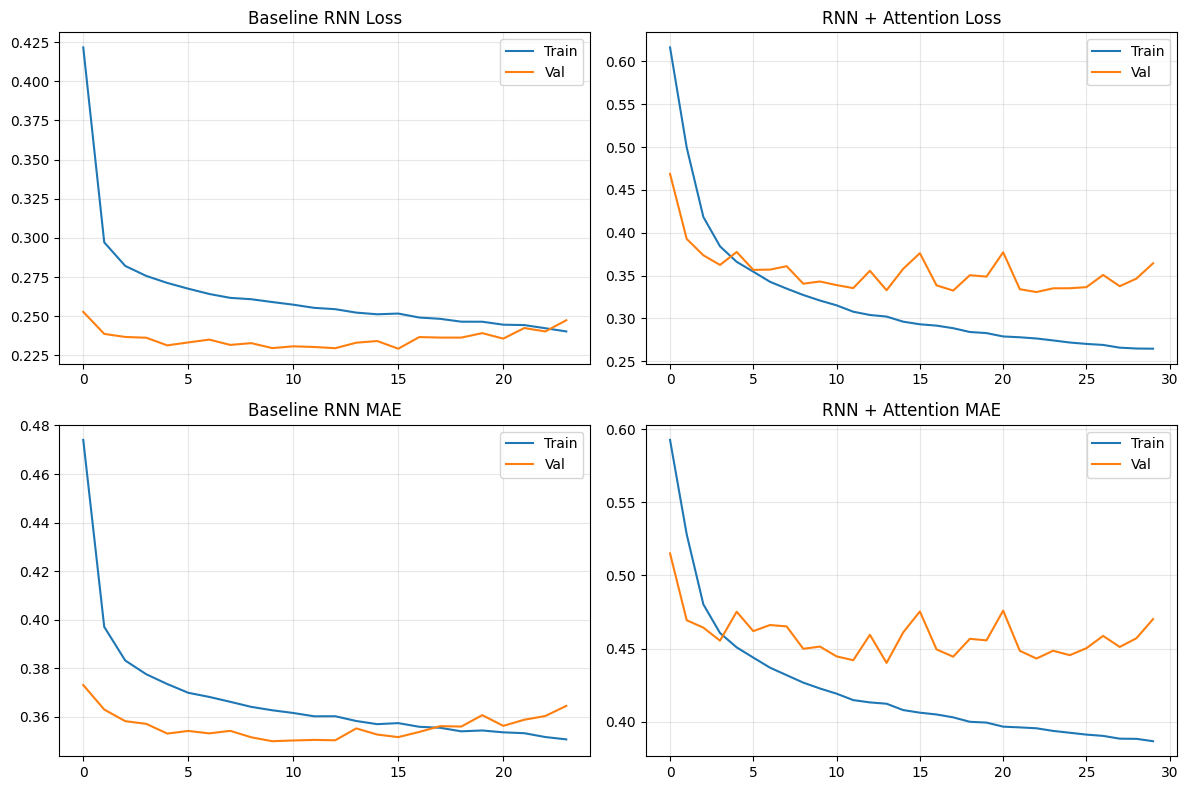

In [ ]:

import tensorflow as tf
from tensorflow import
 keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# ============================================================
# 1. BASELINE MODEL: SIMPLE RNN (NO ATTENTION)
# ============================================================
def build_simple_rnn_baseline(input_shape, units=32):
    """
    Baseline model:
    - Uses a Simple RNN
    - Only the last hidden state is used for prediction
    """

    inputs = keras.Input(shape=input_shape)

    x = layers.SimpleRNN(
        units=units,
        activation="tanh",
        return_sequences=False  # only return the last hidden state
    )(inputs)

    x = layers.Dropout(0.2)(x)
    x = layers.Dense(16, activation="relu")(x)
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


# ============================================================
# 2. SIMPLE RNN WITH ATTENTION
# ============================================================
def build_simple_rnn_with_attention(input_shape, units=32):
    """
    Simple RNN with Attention:
    - RNN returns ALL timesteps
    - Attention learns which timesteps are more important
    """

    inputs = keras.Input(shape=input_shape)

    # RNN outputs hidden states for all timesteps
    rnn_outputs = layers.SimpleRNN(
        units=units,
        activation="tanh",
        return_sequences=True
    )(inputs)

    # Attention over timesteps
    attention_output = layers.Attention()(
        [rnn_outputs, rnn_outputs]
    )

    # Convert sequence output into a single context vector
    context_vector = layers.GlobalAveragePooling1D()(attention_output)

    x = layers.Dropout(0.2)(context_vector)
    x = layers.Dense(16, activation="relu")(x)
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model


# ============================================================
# 3. TRAINING AND COMPARISON FUNCTION
# ============================================================
def compare_rnn_models(train_dataset, val_dataset, test_dataset, input_shape):
    """
    Trains and compares:
    1) Simple RNN without attention
    2) Simple RNN with attention
    """

    # -------------------------------
    # Train Baseline Model
    # -------------------------------
    print("\n" + "=" * 60)
    print("TRAINING: SIMPLE RNN (NO ATTENTION)")
    print("=" * 60)

    baseline_model = build_simple_rnn_baseline(input_shape)
    baseline_model.summary()

    baseline_history = baseline_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=30,
        verbose=1,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=8,
                restore_best_weights=True
            )
        ]
    )

    # -------------------------------
    # Train Attention Model
    # -------------------------------
    print("\n" + "=" * 60)
    print("TRAINING: SIMPLE RNN WITH ATTENTION")
    print("=" * 60)

    attention_model = build_simple_rnn_with_attention(input_shape)
    attention_model.summary()

    attention_history = attention_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=30,
        verbose=1,
        callbacks=[
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=8,
                restore_best_weights=True
            )
        ]
    )

    # -------------------------------
    # Evaluation
    # -------------------------------
    print("\n" + "=" * 60)
    print("TEST SET EVALUATION")
    print("=" * 60)

    baseline_loss, baseline_mae = baseline_model.evaluate(
        test_dataset, verbose=0
    )
    attention_loss, attention_mae = attention_model.evaluate(
        test_dataset, verbose=0
    )

    print(f"Baseline RNN     → Test MSE: {baseline_loss:.4f}, MAE: {baseline_mae:.4f}")
    print(f"RNN + Attention  → Test MSE: {attention_loss:.4f}, MAE: {attention_mae:.4f}")

    # -------------------------------
    # Performance Comparison
    # -------------------------------
    mae_diff = attention_mae - baseline_mae
    loss_diff = attention_loss - baseline_loss

    print("\n" + "=" * 60)
    print("PERFORMANCE DIFFERENCE (ATTENTION - BASELINE)")
    print("=" * 60)
    print(f"MAE Difference : {mae_diff:+.4f}")
    print(f"MSE Difference : {loss_diff:+.4f}")

    # -------------------------------
    # Plot Training Curves
    # -------------------------------
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Loss
    axes[0, 0].plot(baseline_history.history["loss"], label="Train")
    axes[0, 0].plot(baseline_history.history["val_loss"], label="Val")
    axes[0, 0].set_title("Baseline RNN Loss")
    axes[0, 0].legend()
    axes[0, 0].grid(alpha=0.3)

    axes[0, 1].plot(attention_history.history["loss"], label="Train")
    axes[0, 1].plot(attention_history.history["val_loss"], label="Val")
    axes[0, 1].set_title("RNN + Attention Loss")
    axes[0, 1].legend()
    axes[0, 1].grid(alpha=0.3)

    # MAE
    axes[1, 0].plot(baseline_history.history["mae"], label="Train")
    axes[1, 0].plot(baseline_history.history["val_mae"], label="Val")
    axes[1, 0].set_title("Baseline RNN MAE")
    axes[1, 0].legend()
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].plot(attention_history.history["mae"], label="Train")
    axes[1, 1].plot(attention_history.history["val_mae"], label="Val")
    axes[1, 1].set_title("RNN + Attention MAE")
    axes[1, 1].legend()
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    return baseline_model, attention_model


# ============================================================
# 4. MAIN EXECUTION
# ============================================================
print("Reading input shape from dataset...")

for x_batch, y_batch in train_dataset.take(1):
    input_shape = x_batch.shape[1:]  # (sequence_length, num_features)
    print(f"Input shape: {input_shape}")
    break

print("\nStarting model comparison...")
baseline_model, attention_model = compare_rnn_models(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    input_shape=input_shape
)


In [ ]:
import os

# Create a directory to save the model if it doesn't exist
model_dir = 'saved_models'
os.makedirs(model_dir, exist_ok=True)

# Save the attention model
attention_model.save(os.path.join(model_dir, 'rnn_with_attention_model.keras'))

print(f"RNN with Attention model saved to '{os.path.join(model_dir, 'rnn_with_attention_model.keras')}'")

RNN with Attention model saved to 'saved_models/rnn_with_attention_model.keras'


We can load the model later (For streamlit purpose) using:

```python
from tensorflow import keras
loaded_model = keras.models.load_model('saved_models/rnn_with_attention_model.keras')
```